In [1]:
from __future__ import annotations

import anndata as ad
import pooch
import scanpy as sc
import umap

import umapjax

/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [3]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/adamgayoso/Software/umapjax/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [4]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [5]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

In [6]:
ref_model = umap.UMAP(n_neighbors=15)
adata.obsm["X_umap_ref"] = ref_model.fit_transform(adata.obsm["X_pca"])

In [ ]:
jax_model = umapjax.UmapJax(n_neighbors=15, n_epochs=1000)
adata.obsm["X_umap_jax"] = jax_model.fit_transform(adata.obsm["X_pca"])

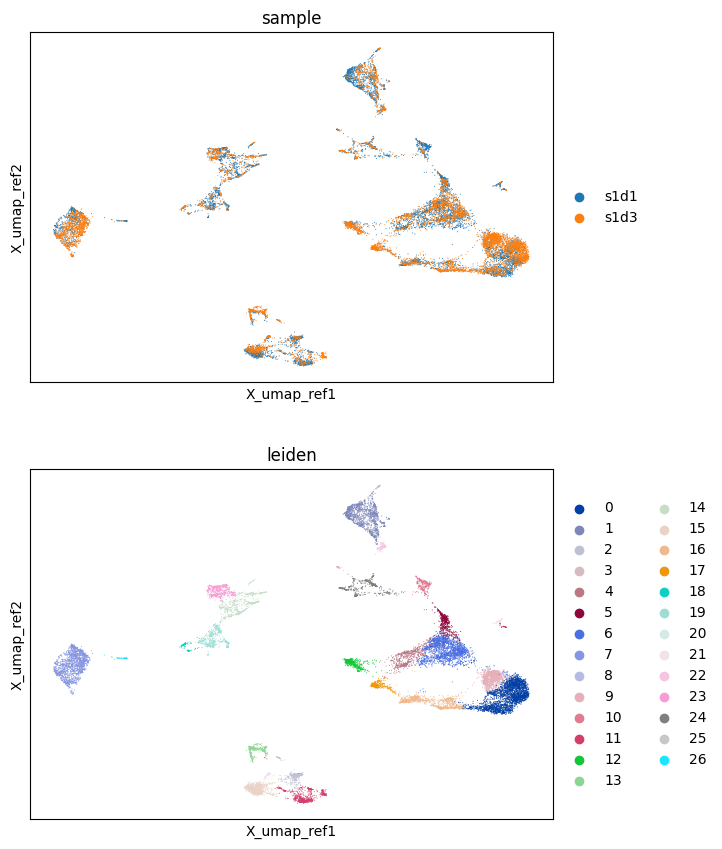

In [10]:
sc.pl.embedding(adata, color=["sample", "leiden"], size=2, basis="X_umap_ref", ncols=1)

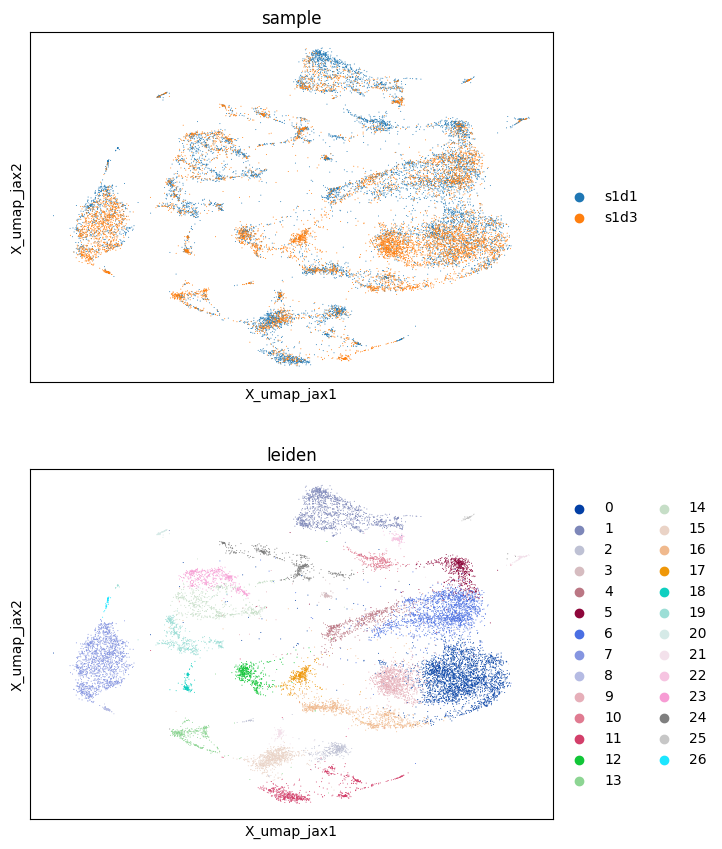

In [11]:
sc.pl.embedding(adata, color=["sample", "leiden"], size=2, basis="X_umap_jax", ncols=1)